In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [48]:
df = pd.read_csv(r"E:\vs\module 2\Assignment 1 Customer Churn Prediction with Logistic Regression\Churn.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [50]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)


print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


C:\Users\ADS2609026\AppData\Local\Temp\22\ipykernel_21024\4272455105.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


In [51]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [52]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after conversion:")
print(df.isnull().sum())

Missing values after conversion:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [53]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [54]:
churn_counts = df["Churn"].value_counts()

print("Churn distribution:")
print(churn_counts)

churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"\nOverall churn rate: {churn_rate:.2f}%")

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall churn rate: 26.54%


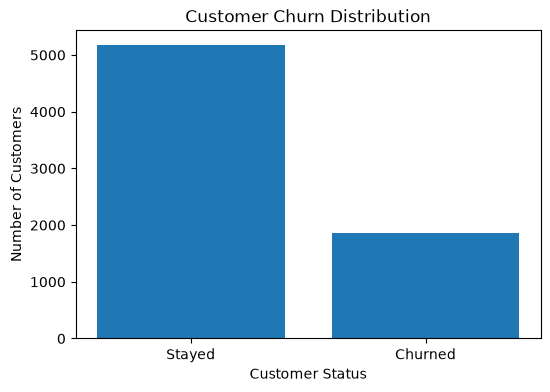

In [55]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Stayed", "Churned"],
    [
        (df["Churn"] == "No").sum(),
        (df["Churn"] == "Yes").sum()
    ]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()

In [56]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


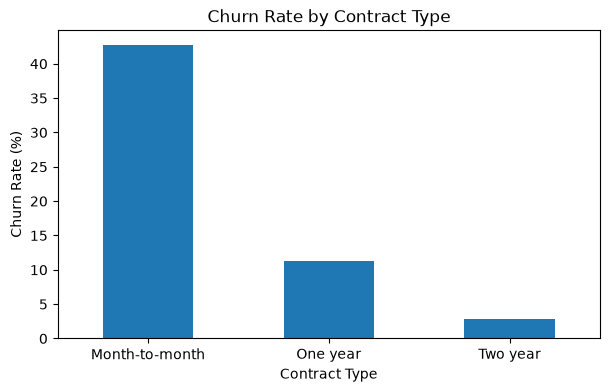

In [57]:
contract_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


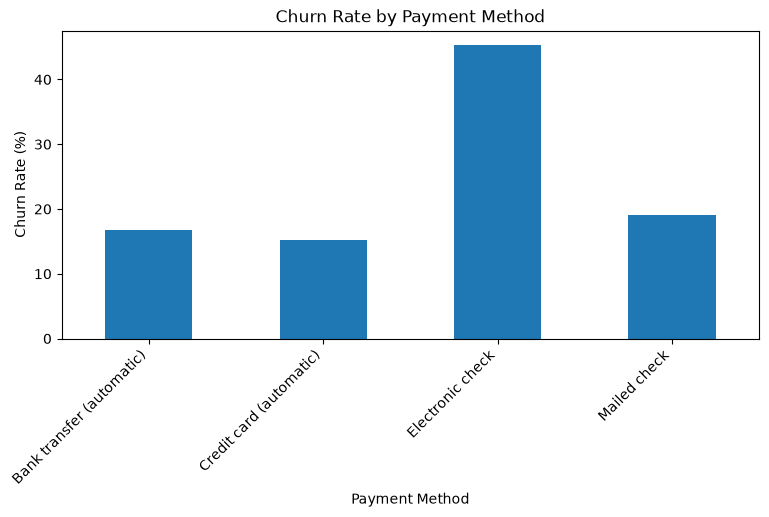

In [58]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)
payment_churn["Yes"].plot(kind="bar", figsize=(9, 4))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

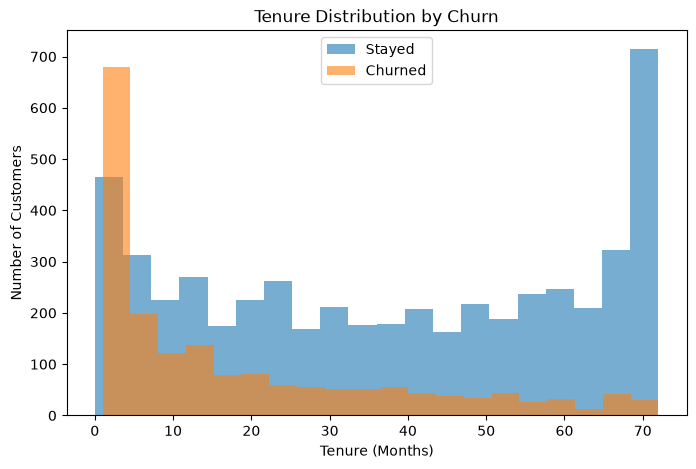

In [59]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Churn"] == "No"]["tenure"],
    bins=20,
    alpha=0.6,
    label="Stayed"
)

plt.hist(
    df[df["Churn"] == "Yes"]["tenure"],
    bins=20,
    alpha=0.6,
    label="Churned"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

In [60]:
df["AvgMonthlyCharges"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

df[["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlyCharges"]].head()

,tenure,MonthlyCharges,TotalCharges,AvgMonthlyCharges
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000


In [61]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [62]:
df = df.drop("customerID", axis=1)

In [63]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [64]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Number of features after encoding:", X.shape[1])
print(X.head())

Number of features after encoding: 31
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  AvgMonthlyCharges  \
0              0       1           29.85         29.85          29.850000   
1              0      34           56.95       1889.50          55.573529   
2              0       2           53.85        108.15          54.075000   
3              0      45           42.30       1840.75          40.905556   
4              0       2           70.70        151.65          75.825000   

   gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            0            1               0                 0   
1            1            0               0                 1   
2            1            0               0                 1   
3            1            0               0                 0   
4            0            0               0                 1   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                               1

In [65]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test.shape)

Training data: (4225, 31)
Validation data: (1409, 31)
Testing data: (1409, 31)


In [66]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [67]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [68]:
def train_logistic_regression(X, y, learning_rate=0.01, iterations=1000):
    
    n_samples, n_features = X.shape
    
    weights = np.zeros(n_features)
    bias = 0
    
    costs = []
    
    for i in range(iterations):
        
        # Calculate prediction probability
        linear_output = np.dot(X, weights) + bias
        predictions = sigmoid(linear_output)
        
        # Calculate log-likelihood cost
        epsilon = 1e-15
        
        cost = -np.mean(
            y * np.log(predictions + epsilon) +
            (1 - y) * np.log(1 - predictions + epsilon)
        )
        
        costs.append(cost)
        
        # Calculate gradients
        dw = np.dot(X.T, (predictions - y)) / n_samples
        db = np.mean(predictions - y)
        
        # Update weights
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db
    
    return weights, bias, costs

In [69]:
learning_rates = [0.001, 0.01, 0.1, 1.0]

results = {}

for lr in learning_rates:
    
    weights, bias, costs = train_logistic_regression(
        X_train_scaled,
        y_train.values,
        learning_rate=lr,
        iterations=1000
    )
    
    results[lr] = {
        "weights": weights,
        "bias": bias,
        "costs": costs
    }
    
    print(f"Learning Rate: {lr}")
    print(f"Initial Cost: {costs[0]:.4f}")
    print(f"Final Cost: {costs[-1]:.4f}")
    print()

Learning Rate: 0.001
Initial Cost: 0.6931
Final Cost: 0.5607

Learning Rate: 0.01
Initial Cost: 0.6931
Final Cost: 0.4310

Learning Rate: 0.1
Initial Cost: 0.6931
Final Cost: 0.4151

Learning Rate: 1.0
Initial Cost: 0.6931
Final Cost: 0.4135



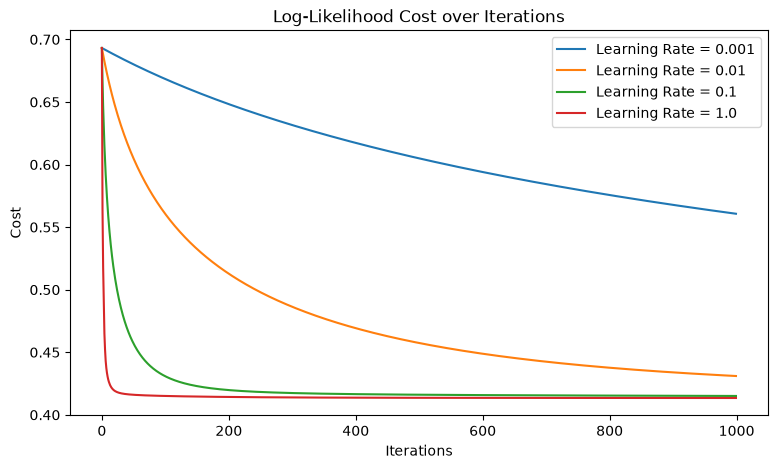

In [70]:
plt.figure(figsize=(9, 5))

for lr in learning_rates:
    plt.plot(
        results[lr]["costs"],
        label=f"Learning Rate = {lr}"
    )

plt.title("Log-Likelihood Cost over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.show()

In [71]:
def predict_probability(X, weights, bias):
    return sigmoid(np.dot(X, weights) + bias)


def predict_class(X, weights, bias, threshold=0.5):
    probabilities = predict_probability(X, weights, bias)
    return (probabilities >= threshold).astype(int)

In [72]:
validation_results = {}

for lr in learning_rates:
    
    weights = results[lr]["weights"]
    bias = results[lr]["bias"]
    
    val_probabilities = predict_probability(
        X_val_scaled,
        weights,
        bias
    )
    
    val_predictions = (val_probabilities >= 0.5).astype(int)
    
    accuracy = np.mean(val_predictions == y_val.values)
    
    validation_results[lr] = accuracy
    
    print(f"Learning Rate {lr}: Validation Accuracy = {accuracy:.4f}")

Learning Rate 0.001: Validation Accuracy = 0.7424
Learning Rate 0.01: Validation Accuracy = 0.8077
Learning Rate 0.1: Validation Accuracy = 0.8162
Learning Rate 1.0: Validation Accuracy = 0.8240


In [73]:
best_learning_rate = max(
    validation_results,
    key=validation_results.get
)

print("Best learning rate:", best_learning_rate)

Best learning rate: 1.0


In [74]:
weights = results[best_learning_rate]["weights"]
bias = results[best_learning_rate]["bias"]

test_probabilities = predict_probability(
    X_test_scaled,
    weights,
    bias
)

test_predictions = (test_probabilities >= 0.5).astype(int)

In [75]:
actual = y_test.values
predicted = test_predictions

TP = np.sum((actual == 1) & (predicted == 1))
TN = np.sum((actual == 0) & (predicted == 0))
FP = np.sum((actual == 0) & (predicted == 1))
FN = np.sum((actual == 1) & (predicted == 0))

print("True Positive :", TP)
print("True Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)

True Positive : 197
True Negative : 912
False Positive: 123
False Negative: 177


In [76]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) > 0 else 0

recall = TP / (TP + FN) if (TP + FN) > 0 else 0

f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1_score:.4f}")

Accuracy : 0.7871
Precision: 0.6156
Recall   : 0.5267
F1-score : 0.5677


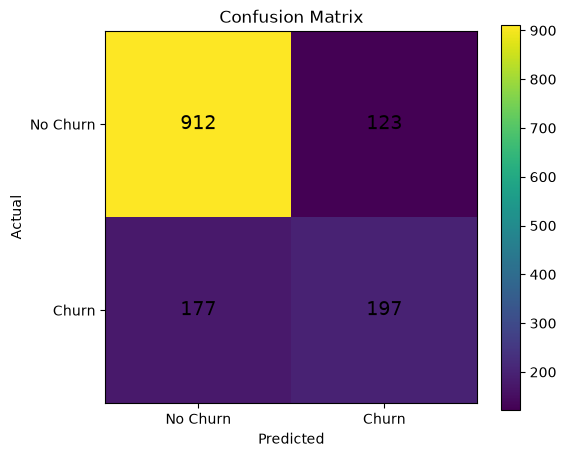

In [77]:
confusion_matrix = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(6, 5))

plt.imshow(confusion_matrix)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()
plt.show()

In [78]:
thresholds = np.linspace(1, 0, 101)

tpr_values = []
fpr_values = []

for threshold in thresholds:
    
    predictions = (test_probabilities >= threshold).astype(int)
    
    tp = np.sum((actual == 1) & (predictions == 1))
    tn = np.sum((actual == 0) & (predictions == 0))
    fp = np.sum((actual == 0) & (predictions == 1))
    fn = np.sum((actual == 1) & (predictions == 0))
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    tpr_values.append(tpr)
    fpr_values.append(fpr)

In [79]:
fpr_values = np.array(fpr_values)
tpr_values = np.array(tpr_values)

sort_indices = np.argsort(fpr_values)

fpr_sorted = fpr_values[sort_indices]
tpr_sorted = tpr_values[sort_indices]

auc = np.trapezoid(tpr_sorted, fpr_sorted)

print(f"AUC: {auc:.4f}")

AUC: 0.8321


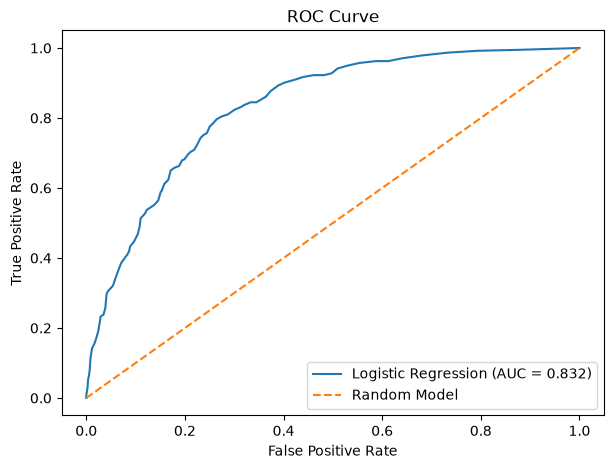

In [80]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr_sorted,
    tpr_sorted,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [81]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": weights
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.287350,1.287350
3,TotalCharges,0.611593,0.611593
26,Contract_Two year,-0.596447,0.596447
11,InternetService_Fiber optic,0.399997,0.399997
25,Contract_One year,-0.291092,0.291092
29,PaymentMethod_Electronic check,0.195446,0.195446
27,PaperlessBilling_Yes,0.190259,0.190259
14,OnlineSecurity_Yes,-0.184963,0.184963
20,TechSupport_Yes,-0.182127,0.182127
10,MultipleLines_Yes,0.142200,0.142200


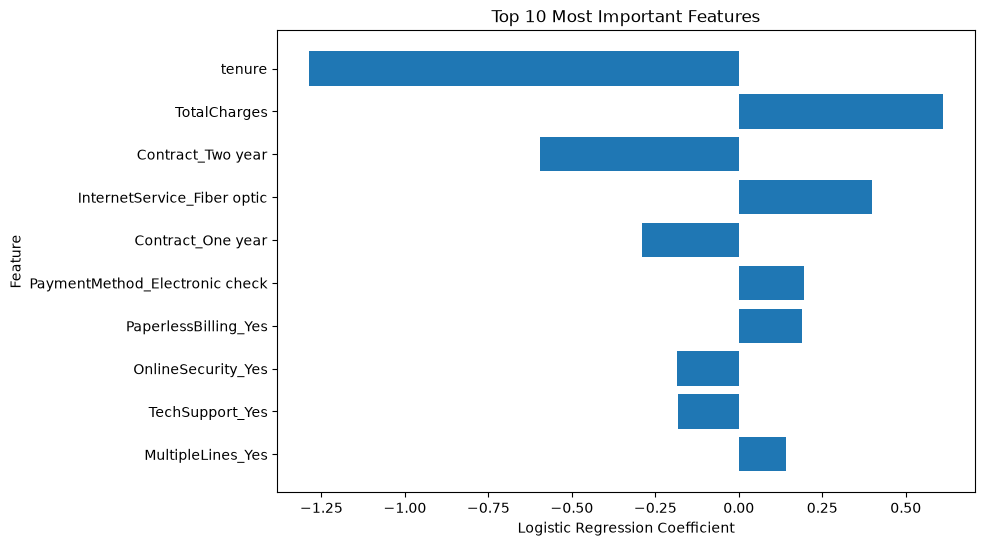

In [82]:
top_10 = feature_importance.head(10)

plt.figure(figsize=(9, 6))

plt.barh(
    top_10["Feature"],
    top_10["Coefficient"]
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()

plt.show()

In [83]:
print("Top 10 features and their effect on churn:\n")

for _, row in top_10.iterrows():
    
    feature = row["Feature"]
    coefficient = row["Coefficient"]
    
    if coefficient > 0:
        effect = "increases the likelihood of churn"
    else:
        effect = "decreases the likelihood of churn"
    
    print(
        f"{feature}: coefficient = {coefficient:.4f} "
        f"→ {effect}"
    )

Top 10 features and their effect on churn:

tenure: coefficient = -1.2873 → decreases the likelihood of churn
TotalCharges: coefficient = 0.6116 → increases the likelihood of churn
Contract_Two year: coefficient = -0.5964 → decreases the likelihood of churn
InternetService_Fiber optic: coefficient = 0.4000 → increases the likelihood of churn
Contract_One year: coefficient = -0.2911 → decreases the likelihood of churn
PaymentMethod_Electronic check: coefficient = 0.1954 → increases the likelihood of churn
PaperlessBilling_Yes: coefficient = 0.1903 → increases the likelihood of churn
OnlineSecurity_Yes: coefficient = -0.1850 → decreases the likelihood of churn
TechSupport_Yes: coefficient = -0.1821 → decreases the likelihood of churn
MultipleLines_Yes: coefficient = 0.1422 → increases the likelihood of churn


In [84]:
test_results = X_test.copy()

test_results["Actual_Churn"] = y_test.values
test_results["Churn_Probability"] = test_probabilities
test_results["Predicted_Churn"] = test_predictions

test_results.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Churn_Probability,Predicted_Churn
2881,0,31,64.00,1910.75,61.637097,0,1,0,1,0,...,1,1,0,1,0,1,0,0,0.093386,0
3994,1,54,101.50,5373.10,99.501852,0,1,0,1,0,...,1,1,0,1,1,0,0,1,0.259471,0
2663,0,59,109.15,6557.75,111.148305,0,1,0,1,0,...,1,1,0,1,1,0,0,0,0.174890,0
3195,0,9,80.55,653.90,72.655556,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0.505899,1
5093,0,49,66.15,3199.00,65.285714,1,0,0,1,0,...,0,0,1,1,0,0,0,0,0.035778,0


In [85]:
original_df = pd.read_csv(
    "Churn.csv"
)

original_df["TotalCharges"] = pd.to_numeric(
    original_df["TotalCharges"],
    errors="coerce"
)

original_df["TotalCharges"] = original_df["TotalCharges"].fillna(
    original_df["TotalCharges"].median()
)

original_df["Churn"] = original_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [86]:
churned_customers = original_df[
    original_df["Churn"] == 1
]

number_of_churned_customers = len(churned_customers)

average_monthly_charge = churned_customers[
    "MonthlyCharges"
].mean()

estimated_annual_revenue_loss = (
    number_of_churned_customers
    * average_monthly_charge
    * 12
)

print("Number of churned customers:",
      number_of_churned_customers)

print(
    f"Average monthly charge of churned customers: "
    f"${average_monthly_charge:.2f}"
)

print(
    f"Estimated one-year revenue at risk: "
    f"${estimated_annual_revenue_loss:,.2f}"
)

Number of churned customers: 1869
Average monthly charge of churned customers: $74.44
Estimated one-year revenue at risk: $1,669,570.20


In [87]:
print("Business Recommendations:\n")

print("1. Focus retention efforts on customers with high churn probability.")

print("2. Encourage customers to move from month-to-month contracts "
      "to longer-term contracts.")

print("3. Monitor customers with high monthly charges because they "
      "may have greater revenue impact.")

print("4. Improve customer support and service quality for customers "
      "showing signs of dissatisfaction.")

print("5. Provide suitable discounts or loyalty benefits to high-risk "
      "customers before they churn.")

print("6. Use the model's churn probability to prioritize retention "
      "campaigns instead of treating every customer equally.")

Business Recommendations:

1. Focus retention efforts on customers with high churn probability.
2. Encourage customers to move from month-to-month contracts to longer-term contracts.
3. Monitor customers with high monthly charges because they may have greater revenue impact.
4. Improve customer support and service quality for customers showing signs of dissatisfaction.
5. Provide suitable discounts or loyalty benefits to high-risk customers before they churn.
6. Use the model's churn probability to prioritize retention campaigns instead of treating every customer equally.


In [88]:
summary = pd.DataFrame({
    "Metric": [
        "Best Learning Rate",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],
    "Value": [
        best_learning_rate,
        accuracy,
        precision,
        recall,
        f1_score,
        auc
    ]
})

summary

,Metric,Value
0,Best Learning Rate,1.000000
1,Accuracy,0.787083
2,Precision,0.615625
3,Recall,0.526738
4,F1-score,0.567723
5,AUC,0.832067
